# KNN Project
## Wine Quality Classifiaction

MSalaverri

Classify red wines into three quality categories based on their chemical composition.

**Type of Problem:** Multiclass classification using **KNN**.

In [177]:
# IMPORT LIBRARIES

# Data manipulation & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter

# Saving models
import joblib

import warnings
warnings.filterwarnings('ignore')


In [178]:
# LOADING ORIGINAL DATA
data = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(data,delimiter=";")

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Exploratory Data Analysis

In [179]:
#Dataset dimension
rows, column = df.shape
print("DATASET Dimension:")
print(f'{rows} rows and {column} columns')

DATASET Dimension:
1599 rows and 12 columns


In [180]:
# Get information about range index, number of columns and labels, data types, and the number of cells in each column (non-null values)
print("DATASET General Info:")
df.info()

DATASET General Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [181]:
#List Missing values
all_missing_values = df.isnull().sum()
print("Missing Values per Column:")
all_missing_values.reset_index()

Missing Values per Column:


,index,0
0,fixed acidity,0
1,volatile acidity,0
2,citric acid,0
3,residual sugar,0
4,chlorides,0
5,free sulfur dioxide,0
6,total sulfur dioxide,0
7,density,0
8,pH,0
9,sulphates,0


In [182]:
num_of_zeros = (df == 0).sum()
print("Count of Zeros per Column:")
num_of_zeros.sort_values(ascending=False).reset_index()

Count of Zeros per Column:


,index,0
0,citric acid,132
1,fixed acidity,0
2,volatile acidity,0
3,residual sugar,0
4,chlorides,0
5,free sulfur dioxide,0
6,total sulfur dioxide,0
7,density,0
8,pH,0
9,sulphates,0


In [183]:
print("\nDESCRIPTIVE BASIC STATISTIC:")
df.describe()


DESCRIPTIVE BASIC STATISTIC:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Initial Inspection Summary
The dataset contains 1,599 rows and 12 columns, each row representing a red wine sample from the UCI Wine Quality dataset.

All columns are fully populated, with no missing values reported. The dataset is rich in chemical features, making it suitable for classification tasks.

The dataset includes:

- 11 predictor variables (float64):

- fixed acidity, volatile acidity, citric acid

- residual sugar, chlorides

- free sulfur dioxide, total sulfur dioxide

- density, pH, sulphates, alcohol

**Quality** is the Targget Variable. Values ggo from 3 to 8 

Comment: The dataset is clean and numeric, making it suitable for KNN. Scaling is essential because KNN relies on distance metrics, and features like alcohol and sulphates may dominate if not normalized.

### Data Prep

#### DUplicates

In [184]:
#Looking for Duplicates
duplicates = df.duplicated()
sum_duplicates = duplicates.sum()

# Verifying Duplicates
print(f"Duplicated Rows: {sum_duplicates}")

df = df.drop_duplicates()
rows, column = df.shape
print("\nNEW DATASET Dimension (after removing duplicates):")
print(f'{rows} rows and {column} columns')

Duplicated Rows: 240

NEW DATASET Dimension (after removing duplicates):
1359 rows and 12 columns


### Visualization and Data Analysis

#### Unique

In [185]:
#Show Unique values per column name
n_uniques = df.nunique()
n_uniques.reset_index()

,index,0
0,fixed acidity,96
1,volatile acidity,143
2,citric acid,80
3,residual sugar,91
4,chlorides,153
5,free sulfur dioxide,60
6,total sulfur dioxide,144
7,density,436
8,pH,89
9,sulphates,96


#### Target Variable Distribution
Note: Target Variable is **Quality**

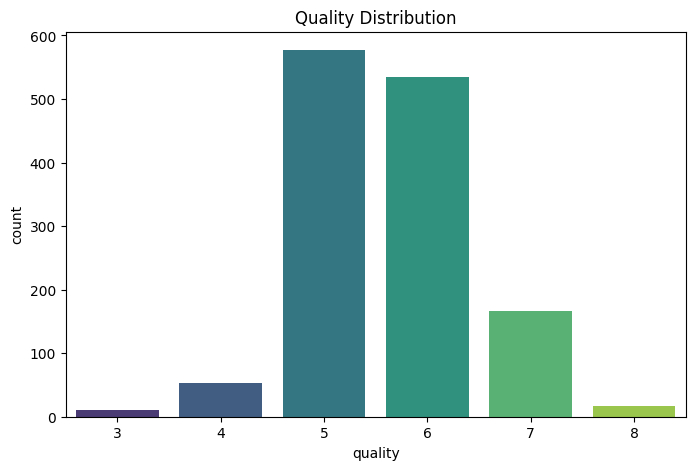

,quality,count
0,5,577
1,6,535
2,7,167
3,4,53
4,8,17
5,3,10


In [186]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='quality', palette="viridis", stat="count")
plt.title("Quality Distribution")
plt.show()

df['quality'].sort_values().value_counts().reset_index()

We need to encode the Target variable as:
 - 0 = low quality (3-4)
 - 1 = medium quality (5-6)
 - 2 = high quality (7-8)

In [187]:
def encoded_new_label(q):
    if q <= 4:
        return 0    # low quality (3-4)
    elif q <= 6:
        return 1    # medium quality (5-6)
    else:
        return 2    # high quality (7-8)

df["quality_label"] = df["quality"].apply(encoded_new_label)

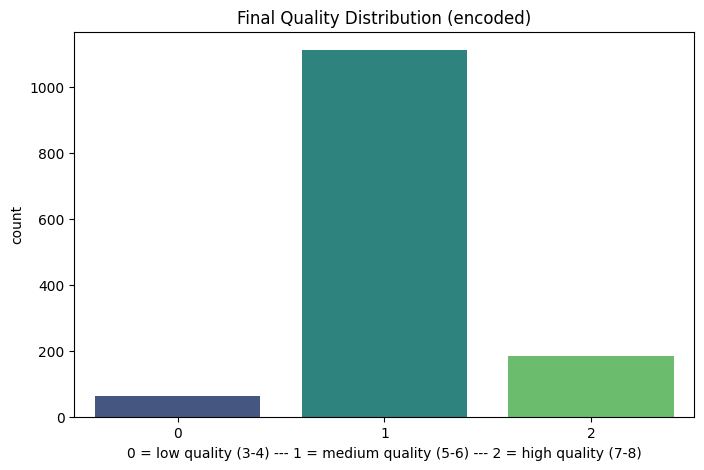

,quality_label,proportion
0,1,81.824871
1,2,13.539367
2,0,4.635762


In [188]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='quality_label', palette="viridis", stat="count")
plt.title("Final Quality Distribution (encoded)")
plt.xlabel("0 = low quality (3-4) --- 1 = medium quality (5-6) --- 2 = high quality (7-8)")
plt.show()

(df['quality_label'].value_counts(normalize=True)*100).reset_index()

#### Correlation Heatmap

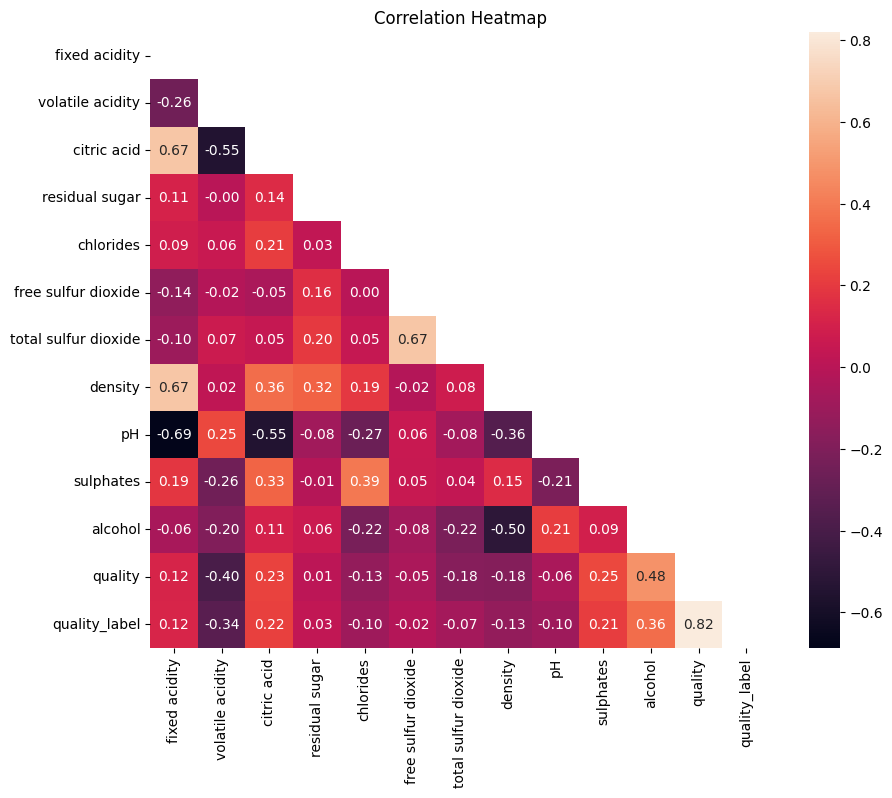


---CORRELATION WITH QUALITY LABEL


,index,quality_label
0,quality_label,1.000000
1,quality,0.820183
2,alcohol,0.358652
3,citric acid,0.223186
4,sulphates,0.208731
5,fixed acidity,0.123416
6,residual sugar,0.030053
7,free sulfur dioxide,-0.018943
8,total sulfur dioxide,-0.070284
9,chlorides,-0.096578


In [189]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(corr)

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print("\n---CORRELATION WITH QUALITY LABEL")
corr['quality_label'].sort_values(ascending=False).reset_index()

## Preprocessing

#### Train & Test

In [190]:
# Features and target
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### SMOTE Balance

In [191]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Train distribution before SMOTE:", Counter(y_train))
print("Train distribution after SMOTE:", Counter(y_train_smote))

Train distribution before SMOTE: Counter({1: 890, 2: 147, 0: 50})
Train distribution after SMOTE: Counter({1: 890, 2: 890, 0: 890})


## Modeling

In [192]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_smote, y_train_smote)

y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6323529411764706

Confusion Matrix:
 [[  7   4   2]
 [ 34 132  56]
 [  0   4  33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.17      0.54      0.26        13
           1       0.94      0.59      0.73       222
           2       0.36      0.89      0.52        37

    accuracy                           0.63       272
   macro avg       0.49      0.67      0.50       272
weighted avg       0.83      0.63      0.68       272



### Optimization

In [193]:
accuracies = []
k_values = range(3, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_smote, y_train_smote)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)


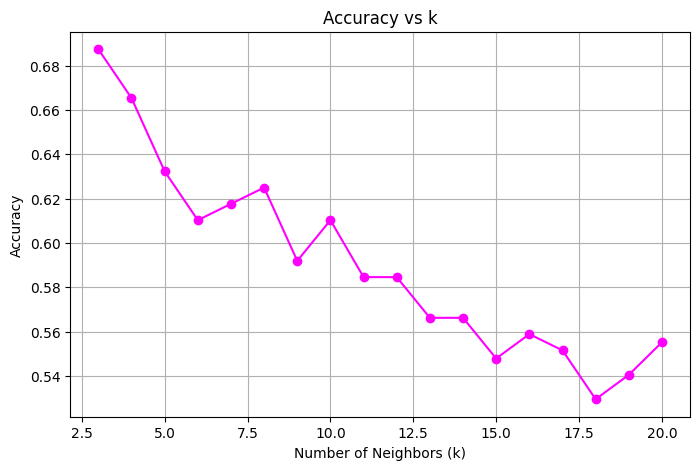

Best k: 3
Accuracy: 0.6875


In [194]:
# Lets plot to identify the Optimal k
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o', color="magenta")
plt.title("Accuracy vs k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

Optimal_k = k_values[np.argmax(accuracies)]
print(f"Best k: {Optimal_k}")
print(f"Accuracy: {max(accuracies):.4f}")

### KNN Model final
After Optimization

In [195]:
knn_opt = KNeighborsClassifier(n_neighbors=Optimal_k)
knn_opt.fit(X_train_smote, y_train_smote)

y_pred = knn_opt.predict(X_test_scaled)

print("\n---OPTIMIZED KNN----")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


---OPTIMIZED KNN----
Accuracy: 0.6875

Confusion Matrix:
 [[  7   5   1]
 [ 25 149  48]
 [  0   6  31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.22      0.54      0.31        13
           1       0.93      0.67      0.78       222
           2       0.39      0.84      0.53        37

    accuracy                           0.69       272
   macro avg       0.51      0.68      0.54       272
weighted avg       0.82      0.69      0.72       272



## Prediction Function

In [196]:
def predict_wine_quality(features):
    features_scaled = scaler.transform([features])
    prediction = knn_opt.predict(features_scaled)[0]
    quality_map = {0: "low quality", 1: "medium quality", 2: "high quality"}
    return f"This wine is probably {quality_map[prediction]}"

print(predict_wine_quality([10.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]))


This wine is probably medium quality


## Final Conclusions
The optimized KNN model with SMOTE achieved an accuracy of about **69%**, showing moderate success in classifying wines into low, medium, and high quality categories.

The confusion matrix indicates the model performs best at identifying **medium‑quality wines (class 1)**, while low‑quality (class 0) and high‑quality (class 2) wines are more challenging, with lower precision but higher recall for class 2. I would also assume that since the dataseet contain more than *81.8% of medium‑quality wines*, the model's accuracy would perform better.

SMOTE helped balance the dataset, improving recall for minority classes. Overall, the model demonstrates that chemical features *can* guide wine quality classification, but further tuning or alternative algorithms may be needed for stronger performance across all classes.

**Conclusion:** KNN provides a reasonable baseline for multiclass wine quality prediction.

In [197]:
joblib.dump(knn_opt, "/workspaces/K-Nearest-Neighbors-msalaverri/models/knn_model_wine.pkl")
joblib.dump(scaler, "/workspaces/K-Nearest-Neighbors-msalaverri/models/knn_scaler.pkl")
print("Otimized model and scaler saved to 'models'")


Otimized model and scaler saved to 'models'
